In [1]:
from gettext import install
import subprocess, sys

packages = ['pandas', 'numpy', 'python-docx']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("All packages installed.")

import pandas as pd

All packages installed.


In [2]:
import os, sys

# loader script lives in CropInsuranceLoss-main and expects to run from there
PROJ = '/Users/coltms/Downloads/543_Project'
os.chdir(os.path.join(PROJ, 'CropInsuranceLoss-main'))
sys.path.insert(0, os.getcwd())

from load_rma_data import colsom_df, sobsccc_df, sobtpu_df

Loading cost-of-loss (colsommonth) data…
  loaded colsom00.txt                    (135,731 rows)
  loaded colsom01.txt                    (141,433 rows)
  loaded colsom02.txt                    (157,583 rows)
  loaded colsom03.txt                    (132,341 rows)
  loaded colsom04.txt                    (142,397 rows)
  loaded colsom05.txt                    (111,115 rows)
  loaded colsom06.txt                    (115,507 rows)
  loaded colsom07.txt                    (110,073 rows)
  loaded colsom08.txt                    (158,290 rows)
  loaded colsom09.txt                    (133,107 rows)
  loaded colsom10.txt                    (120,620 rows)
  loaded colsom11.txt                    (142,289 rows)
  loaded colsom12.txt                    (126,166 rows)
  loaded colsom13.txt                    (141,301 rows)
  loaded colsom90.txt                    (75,672 rows)
  loaded colsom91.txt                    (81,356 rows)
  loaded colsom92.txt                    (74,977 rows)
  loaded c

KeyboardInterrupt: 

In [3]:
# Cause-of-Loss (colsommonth) — 30 columns
print(f"Shape: {colsom_df.shape}")
colsom_df.head()

NameError: name 'colsom_df' is not defined

In [4]:
# State/County/Crop Coverage (sobsccc) — 28 columns
print(f"Shape: {sobsccc_df.shape}")
sobsccc_df.head()
savepath = os.path.join(PROJ, 'data', 'sobsccc.csv')
sobsccc_df.to_csv(savepath, index=False)

NameError: name 'sobsccc_df' is not defined

In [ ]:
# Type/Practice/Unit Structure (sobtpu) — 27 columns
print(f"Shape: {sobtpu_df.shape}")
sobtpu_df.head()
savepath = os.path.join(PROJ, 'data', 'sobtpu.csv')
sobtpu_df.to_csv(savepath, index=False)

Shape: (0, 27)


In [5]:
import numpy as np
import pandas

# ensure quantity column is numeric
sobtpu_df['net_reporting_level_amount'] = pandas.to_numeric(
    sobtpu_df['net_reporting_level_amount'], errors='coerce'
)

# step 1: sum acreage by county-year-commodity (each commodity = one "species")
county_crop = (
    sobtpu_df
    .groupby(['commodity_year', 'state_code', 'county_code', 'commodity_name'],
             as_index=False)['net_reporting_level_amount']
    .sum()
)

# step 2: total acreage per county-year (N)
county_totals = (
    county_crop
    .groupby(['commodity_year', 'state_code', 'county_code'],
             as_index=False)['net_reporting_level_amount']
    .sum()
    .rename(columns={'net_reporting_level_amount': 'total_quantity'})
)

county_crop = county_crop.merge(
    county_totals, on=['commodity_year', 'state_code', 'county_code']
)

# step 3: p_i = n_i / N  then  p_i * ln(p_i), treating p=0 as 0
county_crop['p_i'] = county_crop['net_reporting_level_amount'] / county_crop['total_quantity']
county_crop['p_ln_p'] = county_crop['p_i'].apply(lambda p: p * np.log(p) if p > 0 else 0)

# step 4: H' = -sum(p_i * ln(p_i)) per county-year
shannon = (
    county_crop
    .groupby(['commodity_year', 'state_code', 'county_code'])['p_ln_p']
    .sum()
    .mul(-1)
    .rename('shannon_diversity_index')
    .reset_index()
)

# step 5: merge back onto sobtpu_df
sobtpu_df = sobtpu_df.merge(
    shannon, on=['commodity_year', 'state_code', 'county_code'], how='left'
)

print(f"H' range: {sobtpu_df['shannon_diversity_index'].min():.3f} – {sobtpu_df['shannon_diversity_index'].max():.3f}")
sobtpu_df[['commodity_year', 'state_code', 'county_code', 'commodity_name',
           'shannon_diversity_index']].drop_duplicates().head(10)

NameError: name 'sobtpu_df' is not defined

In [ ]:
print(f"Shape: {sobtpu_df.shape}")
sobtpu_df.head()

Shape: (866199, 28)


,commodity_year,state_code,state_name,state_abbreviation,county_code,county_name,commodity_code,commodity_name,insurance_plan_code,insurance_plan_abbreviation,...,unit_structure_name,net_reporting_level_amount,reporting_level_type,liability_amount,total_premium_amount,subsidy_amount,indemnity_amount,loss_ratio,endorsed_commodity_reporting_level_amount,shannon_diversity_index
0,2004,01,Alabama,AL,001,Autauga,0011,WHEAT,44,CRC,...,Optional Unit,0.0,Acres,.0,.0,0,.0,.00,0,0.919834
1,2004,01,Alabama,AL,001,Autauga,0011,WHEAT,44,CRC,...,Optional Unit,87.0,Acres,4677.0,1411.0,903,.0,.00,0,0.919834
2,2004,01,Alabama,AL,001,Autauga,0011,WHEAT,44,CRC,...,Optional Unit,130.0,Acres,12862.0,1306.0,836,.0,.00,0,0.919834
3,2004,01,Alabama,AL,001,Autauga,0011,WHEAT,44,CRC,...,Basic Unit,87.0,Acres,5416.0,1025.0,605,.0,.00,0,0.919834
4,2004,01,Alabama,AL,001,Autauga,0011,WHEAT,90,APH,...,Optional Unit,0.0,Acres,.0,.0,0,.0,.00,0,0.919834


In [ ]:
sobtpu_df['indemnity_amount'] = pandas.to_numeric(sobtpu_df['indemnity_amount'], errors='coerce')

county_year_df = (
    sobtpu_df
    .groupby(['commodity_year', 'state_code', 'county_code'])
    .agg(
        state_name              = ('state_name',               'first'),
        state_abbreviation      = ('state_abbreviation',       'first'),
        county_name             = ('county_name',              'first'),
        total_acres             = ('net_reporting_level_amount','sum'),
        total_indemnity         = ('indemnity_amount',         'sum'),
        shannon_diversity_index = ('shannon_diversity_index',  'first'),
    )
    .reset_index()
)

county_year_df['indemnity_per_acre'] = (
    county_year_df['total_indemnity'] / county_year_df['total_acres']
)

print(f"Shape: {county_year_df.shape}")
county_year_df.head(40)

Shape: (10449, 10)


,commodity_year,state_code,county_code,state_name,state_abbreviation,county_name,total_acres,total_indemnity,shannon_diversity_index,indemnity_per_acre
0,1999,01,001,Alabama,AL,Autauga,12279.75,123907.0,0.639673,10.090352
1,1999,01,003,Alabama,AL,Baldwin,41448.60,301206.0,1.623262,7.266976
2,1999,01,005,Alabama,AL,Barbour,21103.95,630378.0,1.009027,29.870143
3,1999,01,009,Alabama,AL,Blount,3341.60,12209.0,-0.000000,3.653639
4,1999,01,011,Alabama,AL,Bullock,2670.62,171920.0,0.916281,64.374565
5,1999,01,013,Alabama,AL,Butler,2901.53,65936.0,-0.000000,22.724563
6,1999,01,015,Alabama,AL,Calhoun,5394.33,45978.0,-0.000000,8.523394
7,1999,01,019,Alabama,AL,Cherokee,24602.95,1545310.0,0.666299,62.809948
8,1999,01,021,Alabama,AL,Chilton,3464.90,893789.0,0.739010,257.955208
9,1999,01,023,Alabama,AL,Choctaw,644.60,1621.0,-0.000000,2.514738


                            OLS Regression Results                            
Dep. Variable:     indemnity_per_acre   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     38.24
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           7.20e-10
Time:                        14:07:42   Log-Likelihood:                -18136.
No. Observations:                2755   AIC:                         3.628e+04
Df Residuals:                    2753   BIC:                         3.629e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

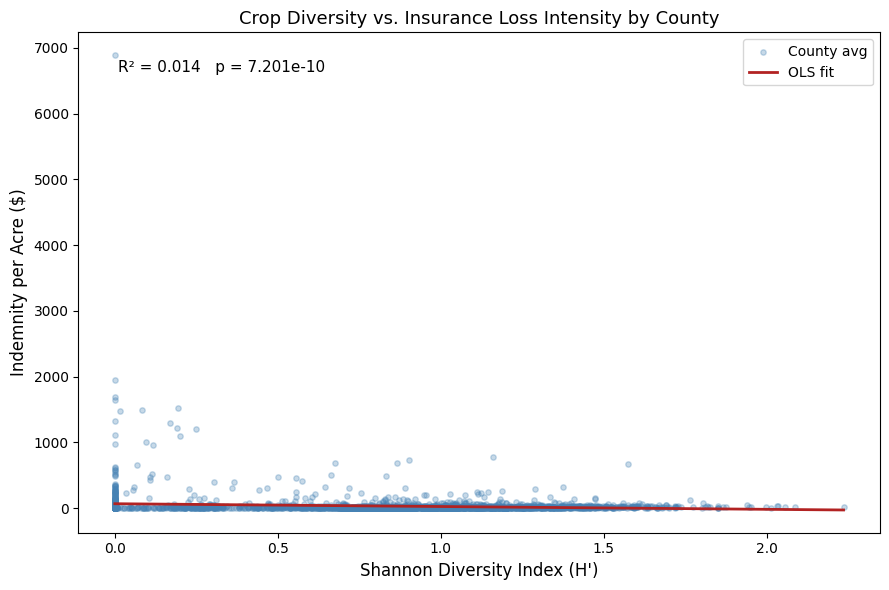

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# average across years so each county is one point
county_df = (
    county_year_df
    .groupby(['state_code', 'county_code', 'county_name', 'state_abbreviation'])[
        ['shannon_diversity_index', 'indemnity_per_acre']
    ]
    .mean()
    .reset_index()
    .dropna()
)

# drop infinite values (counties with 0 acres)
county_df = county_df[np.isfinite(county_df['indemnity_per_acre'])]

# OLS regression
model = smf.ols('indemnity_per_acre ~ shannon_diversity_index', data=county_df).fit()
print(model.summary())

# scatter + regression line
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    county_df['shannon_diversity_index'],
    county_df['indemnity_per_acre'],
    alpha=0.3, s=15, color='steelblue', label='County avg'
)

x_range = np.linspace(county_df['shannon_diversity_index'].min(),
                       county_df['shannon_diversity_index'].max(), 200)
ax.plot(x_range, model.params['Intercept'] + model.params['shannon_diversity_index'] * x_range,
        color='firebrick', linewidth=2, label='OLS fit')

ax.set_xlabel("Shannon Diversity Index (H')", fontsize=12)
ax.set_ylabel("Indemnity per Acre ($)", fontsize=12)
ax.set_title("Crop Diversity vs. Insurance Loss Intensity by County", fontsize=13)
ax.legend()

r2   = model.rsquared
pval = model.pvalues['shannon_diversity_index']
ax.annotate(f"R² = {r2:.3f}   p = {pval:.3e}", xy=(0.05, 0.92),
            xycoords='axes fraction', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# identify the outlier
print(county_df.nlargest(5, 'indemnity_per_acre')[
    ['county_name', 'state_abbreviation', 'shannon_diversity_index', 'indemnity_per_acre']
])

     county_name state_abbreviation  shannon_diversity_index  \
237        Dixie                 FL                 0.000000   
2606        Wise                 VA                 0.000000   
290        Banks                 GA                 0.000000   
77       Bradley                 AR                 0.000000   
1705    Mitchell                 NC                 0.194406   

      indemnity_per_acre  
237          6890.051998  
2606         1954.934371  
290          1696.622517  
77           1647.522829  
1705         1527.156131  


                            OLS Regression Results                            
Dep. Variable:     indemnity_per_acre   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     56.21
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           8.74e-14
Time:                        14:13:19   Log-Likelihood:                -17022.
No. Observations:                2754   AIC:                         3.405e+04
Df Residuals:                    2752   BIC:                         3.406e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

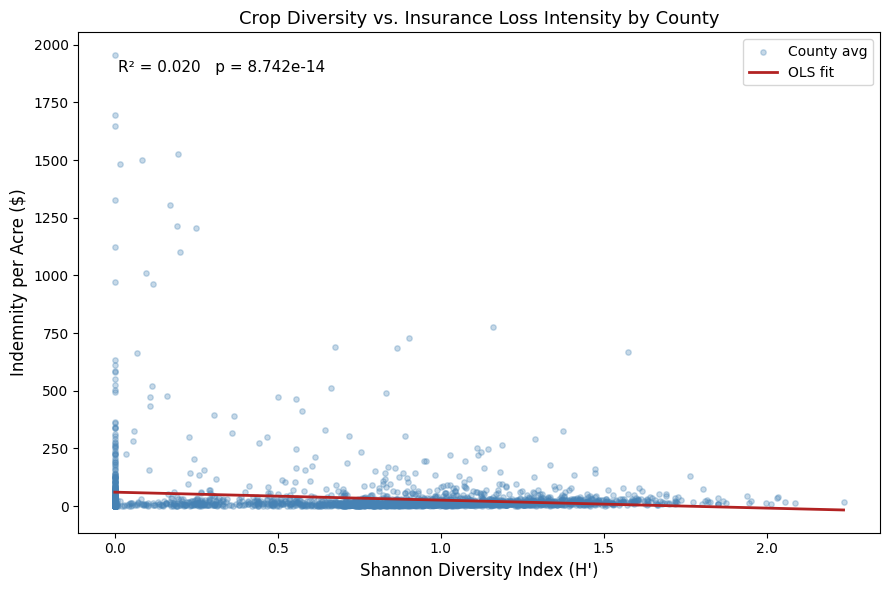

In [ ]:
county_df_clean = county_df[county_df['county_name'] != 'Dixie']

model = smf.ols('indemnity_per_acre ~ shannon_diversity_index', data=county_df_clean).fit()
print(model.summary())

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    county_df_clean['shannon_diversity_index'],
    county_df_clean['indemnity_per_acre'],
    alpha=0.3, s=15, color='steelblue', label='County avg'
)

x_range = np.linspace(county_df_clean['shannon_diversity_index'].min(),
                       county_df_clean['shannon_diversity_index'].max(), 200)
ax.plot(x_range, model.params['Intercept'] + model.params['shannon_diversity_index'] * x_range,
        color='firebrick', linewidth=2, label='OLS fit')

ax.set_xlabel("Shannon Diversity Index (H')", fontsize=12)
ax.set_ylabel("Indemnity per Acre ($)", fontsize=12)
ax.set_title("Crop Diversity vs. Insurance Loss Intensity by County", fontsize=13)
ax.legend()

r2   = model.rsquared
pval = model.pvalues['shannon_diversity_index']
ax.annotate(f"R² = {r2:.3f}   p = {pval:.3e}", xy=(0.05, 0.92),
            xycoords='axes fraction', fontsize=11)

plt.tight_layout()
plt.show()

---
## Crop Diversity & Insurance Risk Analysis
### Hypothesis: Diversified counties show lower *volatility* in claims, even if average loss levels are similar

In [ ]:
# ── Step 1: Compute Simpson (Gini-Simpson) Index ─────────────────────────────
# D = 1 - Σ(p_i²)  →  0 = monoculture, ~1 = highly diverse

county_crop_si = (
    sobtpu_df
    .groupby(['commodity_year', 'state_code', 'county_code', 'commodity_name'],
             as_index=False)['net_reporting_level_amount']
    .sum()
)
totals_si = (
    county_crop_si
    .groupby(['commodity_year', 'state_code', 'county_code'],
             as_index=False)['net_reporting_level_amount']
    .sum()
    .rename(columns={'net_reporting_level_amount': 'total_quantity'})
)
county_crop_si = county_crop_si.merge(totals_si, on=['commodity_year', 'state_code', 'county_code'])
county_crop_si['p_i_sq'] = (county_crop_si['net_reporting_level_amount'] /
                             county_crop_si['total_quantity']) ** 2

simpson = (
    county_crop_si
    .groupby(['commodity_year', 'state_code', 'county_code'])['p_i_sq']
    .sum()
    .rsub(1)
    .rename('simpson_index')
    .reset_index()
)

# drop if already present (idempotent re-run)
if 'simpson_index' in county_year_df.columns:
    county_year_df = county_year_df.drop(columns='simpson_index')

county_year_df = county_year_df.merge(
    simpson, on=['commodity_year', 'state_code', 'county_code'], how='left'
)

print(f"Simpson range: {county_year_df['simpson_index'].min():.3f} – {county_year_df['simpson_index'].max():.3f}")
county_year_df[['commodity_year','county_name','shannon_diversity_index','simpson_index']].head(10)

MergeError: Passing 'suffixes' which cause duplicate columns {'simpson_index_x', 'simpson_index_y'} is not allowed.

In [ ]:
# ── Step 2: County-level summary (collapse across years) ─────────────────────
# Volatility = std dev of indemnity_per_acre across years

county_summary = (
    county_year_df
    .groupby(['state_code', 'county_code', 'county_name', 'state_abbreviation'])
    .agg(
        mean_shannon    = ('shannon_diversity_index', 'mean'),
        mean_simpson    = ('simpson_index',           'mean'),
        mean_indem_acre = ('indemnity_per_acre',      'mean'),
        std_indem_acre  = ('indemnity_per_acre',      'std'),   # volatility
        mean_acres      = ('total_acres',             'mean'),
    )
    .reset_index()
    .dropna()
)

# coefficient of variation = volatility relative to mean (normalises scale differences)
county_summary['cv_indemnity'] = (
    county_summary['std_indem_acre'] / county_summary['mean_indem_acre']
)

# drop Dixie + infinite CV values
county_summary = county_summary[
    (county_summary['county_name'] != 'Dixie') &
    np.isfinite(county_summary['cv_indemnity']) &
    (county_summary['mean_indem_acre'] > 0)
]

print(f"Counties: {len(county_summary)}")
county_summary.head()

Counties: 2659


,state_code,county_code,county_name,state_abbreviation,mean_shannon,mean_simpson,mean_indem_acre,std_indem_acre,mean_acres,cv_indemnity
0,01,001,Autauga,AL,0.746032,0.349827,29.522276,43.892252,11079.95000,1.486750
1,01,003,Baldwin,AL,1.593959,0.730049,20.191078,10.089370,59273.25625,0.499694
2,01,005,Barbour,AL,1.075483,0.585492,80.739532,71.502236,18983.42825,0.885591
3,01,009,Blount,AL,0.250760,0.145151,4.936630,2.967614,3409.17500,0.601142
4,01,011,Bullock,AL,1.042737,0.611975,64.727577,69.678599,2742.56060,1.076490


diversity_category
Moderately Diverse    1225
Highly Diverse         768
Monoculture            666
Name: count, dtype: int64


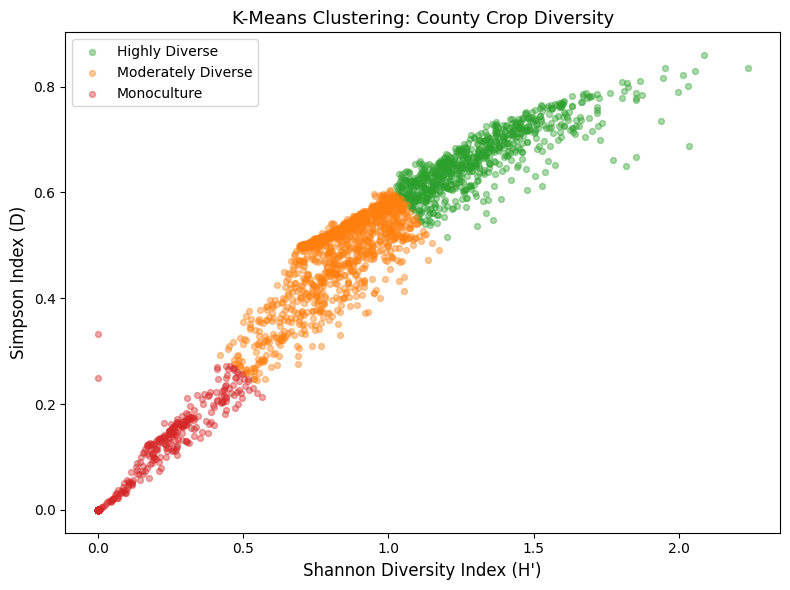

In [ ]:
# ── Step 3: K-Means Clustering on Shannon + Simpson ──────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = county_summary[['mean_shannon', 'mean_simpson']].values
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
county_summary['cluster'] = kmeans.fit_predict(X_scaled)

# label clusters by ascending mean Shannon value
order = (county_summary.groupby('cluster')['mean_shannon']
         .mean().sort_values().index.tolist())
label_map = {order[0]: 'Monoculture',
             order[1]: 'Moderately Diverse',
             order[2]: 'Highly Diverse'}
county_summary['diversity_category'] = county_summary['cluster'].map(label_map)

print(county_summary['diversity_category'].value_counts())

# ── Cluster scatter plot ──────────────────────────────────────────────────────
colors = {'Monoculture': '#d62728',
          'Moderately Diverse': '#ff7f0e',
          'Highly Diverse': '#2ca02c'}

fig, ax = plt.subplots(figsize=(8, 6))
for cat, grp in county_summary.groupby('diversity_category'):
    ax.scatter(grp['mean_shannon'], grp['mean_simpson'],
               label=cat, alpha=0.4, s=18, color=colors[cat])

ax.set_xlabel("Shannon Diversity Index (H')", fontsize=12)
ax.set_ylabel("Simpson Index (D)", fontsize=12)
ax.set_title("K-Means Clustering: County Crop Diversity", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/r1/hzzw22rx3k70tckw2thb5n7c0000gn/T/ipykernel_12170/263724228.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_mean, patch_artist=True, labels=cat_order)
/var/folders/r1/hzzw22rx3k70tckw2thb5n7c0000gn/T/ipykernel_12170/263724228.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_cv, patch_artist=True, labels=cat_order)


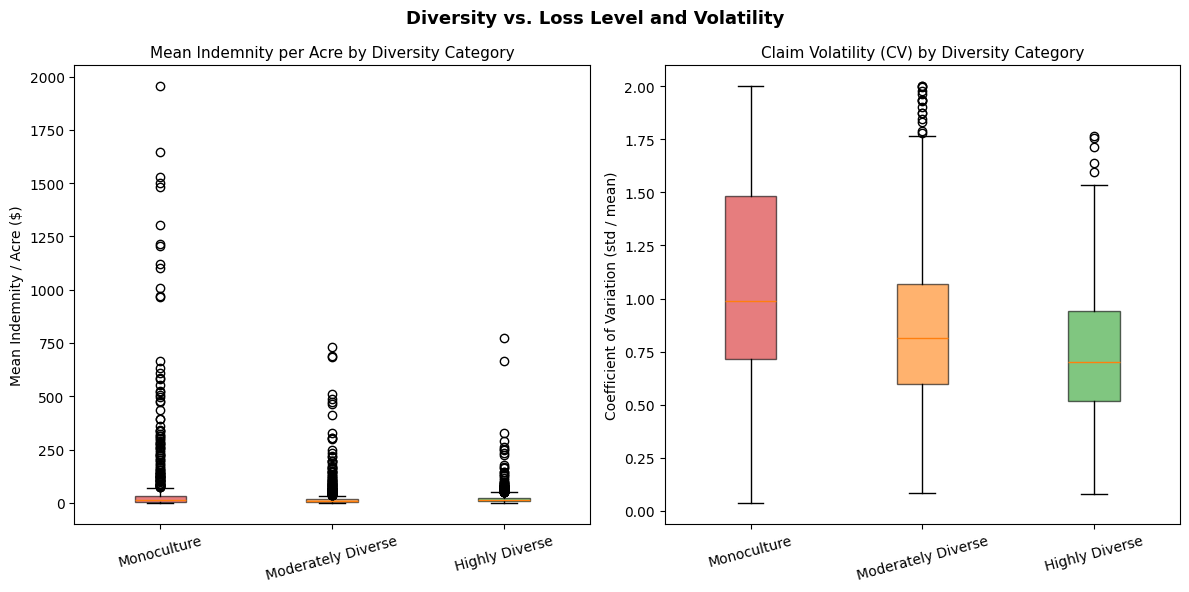

,mean_indem_acre,std_indem_acre,cv_indemnity
diversity_category,,,
Highly Diverse,14.63,9.54,0.70
Moderately Diverse,8.72,7.01,0.81
Monoculture,12.67,11.99,0.99


In [ ]:
# ── Step 4: Volatility Analysis by Cluster ───────────────────────────────────
# Key test: diverse counties should have lower CV (coefficient of variation)
# even if mean indemnity is similar

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cat_order = ['Monoculture', 'Moderately Diverse', 'Highly Diverse']
plot_colors = [colors[c] for c in cat_order]

# panel A — mean indemnity/acre (do diverse counties lose less on average?)
data_mean = [county_summary[county_summary['diversity_category'] == c]['mean_indem_acre'].values
             for c in cat_order]
bp1 = axes[0].boxplot(data_mean, patch_artist=True, labels=cat_order)
for patch, color in zip(bp1['boxes'], plot_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[0].set_title("Mean Indemnity per Acre by Diversity Category", fontsize=11)
axes[0].set_ylabel("Mean Indemnity / Acre ($)")
axes[0].tick_params(axis='x', rotation=15)

# panel B — CV of indemnity (volatility — the key hypothesis test)
data_cv = [county_summary[county_summary['diversity_category'] == c]['cv_indemnity'].values
           for c in cat_order]
bp2 = axes[1].boxplot(data_cv, patch_artist=True, labels=cat_order)
for patch, color in zip(bp2['boxes'], plot_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_title("Claim Volatility (CV) by Diversity Category", fontsize=11)
axes[1].set_ylabel("Coefficient of Variation (std / mean)")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Diversity vs. Loss Level and Volatility", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# summary stats table
county_summary.groupby('diversity_category')[
    ['mean_indem_acre', 'std_indem_acre', 'cv_indemnity']
].median().round(2)

In [ ]:
# ── Step 5: Policy Type features from sobsccc_df ─────────────────────────────
# Compute per-county: mean coverage level + % of liability under buyup (vs CAT)

sobsccc_df['liability_amount'] = pandas.to_numeric(sobsccc_df['liability_amount'], errors='coerce')
sobsccc_df['coverage_level']   = pandas.to_numeric(sobsccc_df['coverage_level'],   errors='coerce')

policy_features = (
    sobsccc_df
    .groupby(['location_state_code', 'location_county_code'])
    .apply(lambda g: pandas.Series({
        'mean_coverage_level': np.average(
            g['coverage_level'].fillna(0),
            weights=g['liability_amount'].fillna(0).clip(lower=0)
        ) if g['liability_amount'].fillna(0).sum() > 0 else np.nan,
        'pct_buyup': (
            g.loc[g['coverage_category'] == 'A', 'liability_amount'].sum() /
            g['liability_amount'].sum()
        ) if g['liability_amount'].sum() > 0 else np.nan,
    }), include_groups=False)
    .reset_index()
    .rename(columns={'location_state_code': 'state_code',
                     'location_county_code': 'county_code'})
)

county_summary = county_summary.merge(policy_features, on=['state_code', 'county_code'], how='left')
print("Policy features added. Nulls:", county_summary[['mean_coverage_level','pct_buyup']].isna().sum().to_dict())
county_summary[['county_name','diversity_category','mean_coverage_level','pct_buyup']].head()

Policy features added. Nulls: {'mean_coverage_level': 0, 'pct_buyup': 0}


,county_name,diversity_category,mean_coverage_level,pct_buyup
0,Autauga,Moderately Diverse,0.634063,0.790479
1,Baldwin,Highly Diverse,0.652856,0.762845
2,Barbour,Highly Diverse,0.699649,0.664216
3,Blount,Monoculture,0.679426,0.925135
4,Bullock,Highly Diverse,0.707976,0.738755


In [ ]:
# ── Step 6: Random Forest — Diversity vs Policy Type as predictors ───────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

rf_df = county_summary[[
    'mean_shannon', 'mean_simpson',          # diversity
    'mean_coverage_level', 'pct_buyup',      # policy type
    'mean_acres',                            # exposure size
    'diversity_category',                    # cluster label
    'mean_indem_acre',                       # target
]].dropna()

le = LabelEncoder()
rf_df = rf_df.copy()
rf_df['diversity_category'] = le.fit_transform(rf_df['diversity_category'])

feature_cols = ['mean_shannon', 'mean_simpson', 'mean_coverage_level',
                'pct_buyup', 'mean_acres', 'diversity_category']

X = rf_df[feature_cols]
y = rf_df['mean_indem_acre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

r2 = r2_score(y_test, rf.predict(X_test))
print(f"Test R²: {r2:.3f}")

# ── Feature importance plot ───────────────────────────────────────────────────
importance = pandas.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_rf = ['#2ca02c' if 'shannon' in f or 'simpson' in f or 'diversity' in f
             else '#1f77b4' for f in importance.index]
importance.plot.barh(ax=ax, color=colors_rf)

ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title("Random Forest: What Predicts Indemnity per Acre?", fontsize=12)

# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ca02c', label='Diversity features'),
                   Patch(color='#1f77b4', label='Policy type / exposure')],
          loc='lower right')
ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

NameError: name 'county_summary' is not defined

In [ ]:
import geopandas as gpd
import os

shp_path = '/Users/coltms/Downloads/543_Project/Farm Resource Regions/tl_2025_us_county/tl_2025_us_county.shp'
gdf_base = gpd.read_file(shp_path)
conus_base = gdf_base[~gdf_base['STATEFP'].isin(['02','15','60','66','69','72','78'])]

simpson_by_year = (
    county_year_df
    .dropna(subset=['simpson_index'])
    .groupby(['commodity_year', 'state_code', 'county_code'])['simpson_index']
    .mean()
    .reset_index()
)

years = sorted(simpson_by_year['commodity_year'].unique())
vmin  = simpson_by_year['simpson_index'].min()
vmax  = simpson_by_year['simpson_index'].max()

out_dir = '/Users/coltms/Downloads/543_Project/simpson_maps'
os.makedirs(out_dir, exist_ok=True)

for year in years:
    yr_data = simpson_by_year[simpson_by_year['commodity_year'] == year]
    gdf = conus_base.merge(
        yr_data,
        left_on=['STATEFP', 'COUNTYFP'],
        right_on=['state_code', 'county_code'],
        how='left'
    )
    fig, ax = plt.subplots(figsize=(16, 9))
    gdf.plot(
        column='simpson_index',
        ax=ax,
        cmap='YlGn',
        vmin=vmin, vmax=vmax,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        legend_kwds={'label': "Simpson Diversity Index (D)", 'shrink': 0.5},
    )
    ax.set_axis_off()
    ax.set_title(f"Crop Diversity by County — Simpson Index ({year})",
                 fontsize=15, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'simpson_{year}.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print(f"saved {year}")

print(f"\nAll maps saved to {out_dir}")

saved 1999
saved 2000
saved 2001
saved 2004

All maps saved to /Users/coltms/Downloads/543_Project/simpson_maps


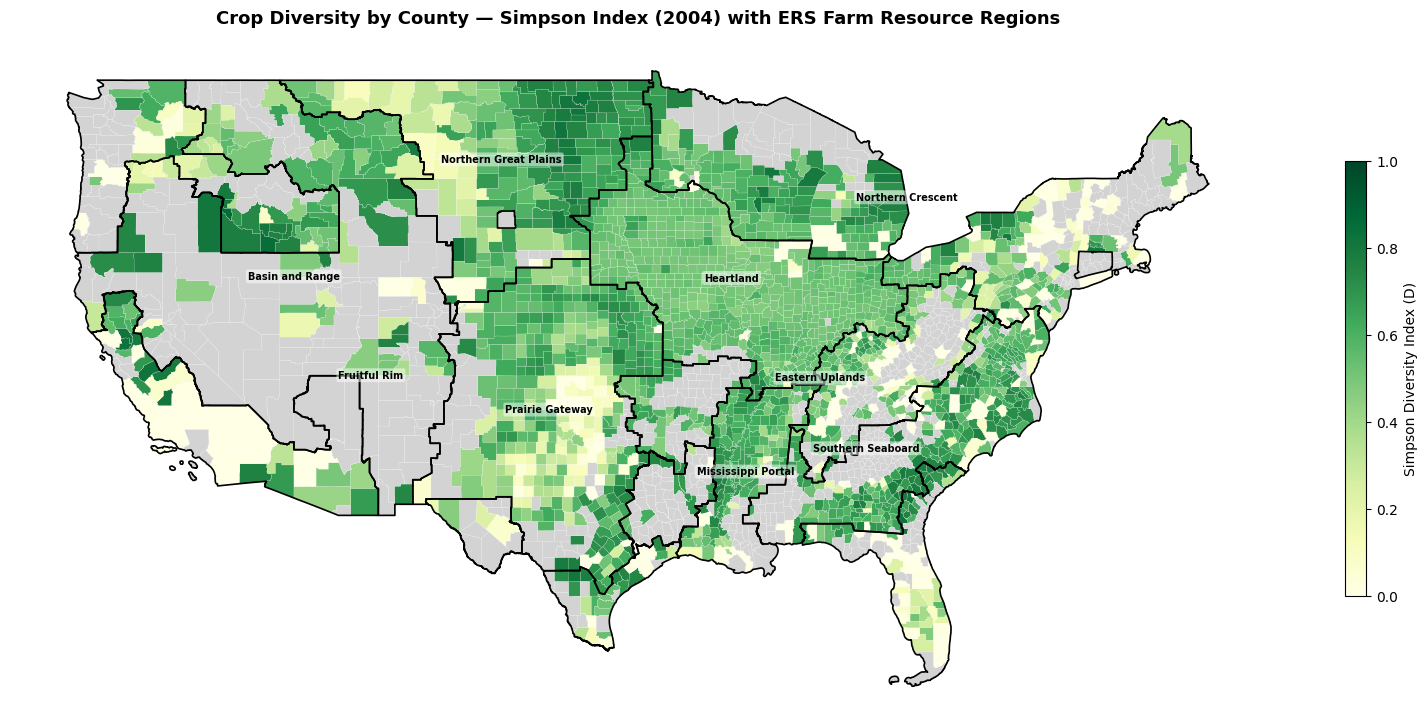

In [ ]:
import geopandas as gpd
import pandas as pd

shp_path = '/Users/coltms/Downloads/543_Project/Farm Resource Regions/tl_2025_us_county/tl_2025_us_county.shp'
gdf_base = gpd.read_file(shp_path)
conus_base = gdf_base[~gdf_base['STATEFP'].isin(['02','15','60','66','69','72','78'])].copy()

# ── Farm Resource Regions from reglink.xls ────────────────────────────────────
reglink = pd.read_excel(
    '/Users/coltms/Downloads/543_Project/Farm Resource Regions/reglink.xls',
    header=2, usecols=['Fips', 'ERS resource region']
).dropna(subset=['Fips', 'ERS resource region'])

region_labels = {
    1: 'Heartland', 2: 'Northern Crescent', 3: 'Northern Great Plains',
    4: 'Prairie Gateway', 5: 'Eastern Uplands', 6: 'Southern Seaboard',
    7: 'Fruitful Rim', 8: 'Basin and Range', 9: 'Mississippi Portal'
}
reglink['GEOID']       = reglink['Fips'].astype(int).astype(str).str.zfill(5)
reglink['region_num']  = reglink['ERS resource region'].astype(int)
reglink['region_name'] = reglink['region_num'].map(region_labels)

# dissolve county geometries → region boundaries
conus_reg = conus_base.merge(reglink[['GEOID','region_name']], on='GEOID', how='left')
region_boundaries = conus_reg.dissolve(by='region_name').reset_index()

# ── 2004 Simpson data ─────────────────────────────────────────────────────────
yr_data = simpson_by_year[simpson_by_year['commodity_year'] == '2004']
gdf_2004 = conus_base.merge(
    yr_data,
    left_on=['STATEFP', 'COUNTYFP'],
    right_on=['state_code', 'county_code'],
    how='left'
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))

gdf_2004.plot(
    column='simpson_index',
    ax=ax,
    cmap='YlGn',
    vmin=vmin, vmax=vmax,
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    legend_kwds={'label': "Simpson Diversity Index (D)", 'shrink': 0.5},
)

# overlay region boundaries
region_boundaries.boundary.plot(ax=ax, color='black', linewidth=1.2)

# label each region at its centroid
for _, row in region_boundaries.iterrows():
    if row['region_name'] and row.geometry:
        c = row.geometry.centroid
        ax.annotate(row['region_name'], xy=(c.x, c.y),
                    ha='center', fontsize=7, fontweight='bold',
                    color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.5, ec='none'))

ax.set_axis_off()
ax.set_title("Crop Diversity by County — Simpson Index (2004) with ERS Farm Resource Regions",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [ ]:
import glob, os
import pandas as pd

BASE     = '/Users/coltms/Downloads/543_Project/crop_loss_data'
DATA_DIR = '/Users/coltms/Downloads/543_Project/data'

COLSOM_COLS = [
    'commodity_year','state_code','state_abbreviation','county_code','county_name',
    'commodity_code','commodity_name','insurance_plan_code','insurance_plan_abbr',
    'coverage_category','stage_code','cause_of_loss_code','cause_of_loss_description',
    'month_of_loss','month_of_loss_name','year_of_loss','policies_earning_premium',
    'policies_indemnified','net_planted_quantity','net_endorsed_acres','liability',
    'total_premium','producer_paid_premium','subsidy','state_private_subsidy',
    'additional_subsidy','efa_premium_discount','net_determined_quantity',
    'indemnity_amount','loss_ratio',
]
SOBSCCC_COLS = [
    'commodity_year','location_state_code','location_state_abbreviation',
    'location_county_code','location_county_name','commodity_code','commodity_name',
    'insurance_plan_code','insurance_plan_abbr','coverage_category','delivery_type',
    'coverage_level','policies_sold_count','policies_earning_premium_count',
    'policies_indemnified_count','units_earning_premium_count','units_indemnified_count',
    'quantity_type','net_reported_quantity','endorsed_companion_acres','liability_amount',
    'total_premium_amount','subsidy_amount','state_private_subsidy','additional_subsidy',
    'efa_premium_discount','indemnity_amount','loss_ratio',
]
SOBTPU_COLS = [
    'commodity_year','state_code','state_name','state_abbreviation','county_code',
    'county_name','commodity_code','commodity_name','insurance_plan_code',
    'insurance_plan_abbreviation','coverage_type_code','coverage_level_percent',
    'delivery_id','type_code','type_name','practice_code','practice_name',
    'unit_structure_code','unit_structure_name','net_reporting_level_amount',
    'reporting_level_type','liability_amount','total_premium_amount','subsidy_amount',
    'indemnity_amount','loss_ratio','endorsed_commodity_reporting_level_amount',
]

def load_txt_dir(folder, cols):
    frames = []
    for path in sorted(glob.glob(f'{folder}/*.txt')):
        df = pd.read_csv(path, sep='|', header=None, names=cols,
                         dtype=str, encoding='latin-1')
        str_cols = df.select_dtypes('object').columns
        df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())
        frames.append(df)
        print(f'  {os.path.basename(path):30s}  {len(df):>10,} rows')
    return pd.concat(frames, ignore_index=True)

datasets = {
    'colsommonth': (f'{BASE}/cost_of_loss',       COLSOM_COLS),
    'sobsccc':     (f'{BASE}/state_county_crop',   SOBSCCC_COLS),
    'sobtpu':      (f'{BASE}/type_practice_usage', SOBTPU_COLS),
}

for name, (folder, cols) in datasets.items():
    print(f'\nLoading {name}...')
    df = load_txt_dir(folder, cols)
    out = f'{DATA_DIR}/{name}.csv'
    df.to_csv(out, index=False)
    print(f'→ saved {len(df):,} rows to {out}')


Loading colsommonth...


/var/folders/r1/hzzw22rx3k70tckw2thb5n7c0000gn/T/ipykernel_4501/2324502591.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes('object').columns


  colsom00.txt                       135,731 rows


/var/folders/r1/hzzw22rx3k70tckw2thb5n7c0000gn/T/ipykernel_4501/2324502591.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes('object').columns


  colsom01.txt                       141,433 rows


...

  sobcov_2023.txt                    153,022 rows


/var/folders/r1/hzzw22rx3k70tckw2thb5n7c0000gn/T/ipykernel_4501/2324502591.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes('object').columns


  sobcov_2024.txt                    152,423 rows


/var/folders/r1/hzzw22rx3k70tckw2thb5n7c0000gn/T/ipykernel_4501/2324502591.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes('object').columns


  sobcov_2025.txt                    155,649 rows


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

corn = pd.read_csv('/Users/coltms/Downloads/543_Project/Experiment_1/CornCostReturn.csv')
corn = corn[
    (corn['Item'] == 'Primary product, grain') &
    (corn['Category'] == 'Gross value of production') &
    (corn['Year'].between(2000, 2024))
].copy()

national = (corn[corn['Region'] == 'U.S. total']
            [['Year', 'Value']].rename(columns={'Value': 'national_avg'}))
regional = (corn[corn['Region'] != 'U.S. total']
            [['Year', 'Region', 'Value']].rename(columns={'Value': 'regional_price'}))
price_df = regional.merge(national, on='Year')
price_df['above_national'] = price_df['regional_price'] > price_df['national_avg']

# Map CSV region names to ERS region names used in reglink
region_name_map = {
    'U.S. total':             None,
    'Heartland':              'Heartland',
    'Northern Crescent':      'Northern Crescent',
    'Northern Great Plains':  'Northern Great Plains',
    'Prairie Gateway':        'Prairie Gateway',
    'Eastern Uplands':        'Eastern Uplands',
    'Southern Seaboard':      'Southern Seaboard',
}
price_df['region_name'] = price_df['Region'].map(region_name_map)
price_df = price_df.dropna(subset=['region_name'])

# Build ERS region geometries
shp_path = '/Users/coltms/Downloads/543_Project/Farm Resource Regions/tl_2025_us_county/tl_2025_us_county.shp'
gdf_base = gpd.read_file(shp_path)
conus_base = gdf_base[~gdf_base['STATEFP'].isin(['02','15','60','66','69','72','78'])].copy()

reglink = pd.read_excel(
    '/Users/coltms/Downloads/543_Project/Farm Resource Regions/reglink.xls',
    header=2, usecols=['Fips', 'ERS resource region']
).dropna(subset=['Fips', 'ERS resource region'])

region_labels = {
    1: 'Heartland', 2: 'Northern Crescent', 3: 'Northern Great Plains',
    4: 'Prairie Gateway', 5: 'Eastern Uplands', 6: 'Southern Seaboard',
    7: 'Fruitful Rim', 8: 'Basin and Range', 9: 'Mississippi Portal'
}
reglink['GEOID']       = reglink['Fips'].astype(int).astype(str).str.zfill(5)
reglink['region_num']  = reglink['ERS resource region'].astype(int)
reglink['region_name'] = reglink['region_num'].map(region_labels)

conus_reg = conus_base.merge(reglink[['GEOID', 'region_name']], on='GEOID', how='left')
region_gdf = conus_reg.dissolve(by='region_name').reset_index()

out_dir = '/Users/coltms/Downloads/543_Project/corn_price_maps'
os.makedirs(out_dir, exist_ok=True)

for year in range(2000, 2025):
    yr = price_df[price_df['Year'] == year]
    if yr.empty:
        continue

    # merge price data onto region geometries
    gdf_yr = region_gdf.merge(yr[['region_name', 'regional_price', 'above_national']],
                               on='region_name', how='left')

    def region_color(row):
        if pd.isna(row['above_national']):
            return '#cccccc'   # no data (Fruitful Rim, Basin and Range, MS Portal)
        return '#2ca02c' if row['above_national'] else '#d62728'

    gdf_yr['color'] = gdf_yr.apply(region_color, axis=1)

    fig, ax = plt.subplots(figsize=(14, 8))
    gdf_yr.plot(color=gdf_yr['color'], ax=ax, edgecolor='white', linewidth=0.5)

    # label each region with name + price
    for _, row in gdf_yr.iterrows():
        if row.geometry is None:
            continue
        c = row.geometry.centroid
        label = row['region_name'] or ''
        if not pd.isna(row.get('regional_price')):
            label += f"\n${row['regional_price']:.0f}/acre"
        ax.annotate(label, xy=(c.x, c.y), ha='center', fontsize=7,
                    fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.2', fc='none', ec='none'))

    # national avg annotation
    nat_avg = national[national['Year'] == year]['national_avg'].values
    if len(nat_avg):
        ax.text(0.01, 0.02, f"US avg: ${nat_avg[0]:.0f}/acre",
                transform=ax.transAxes, fontsize=9, color='black',
                bbox=dict(fc='white', ec='gray', alpha=0.8))

    legend_patches = [
        mpatches.Patch(color='#2ca02c', label='Above national avg'),
        mpatches.Patch(color='#d62728', label='Below national avg'),
        mpatches.Patch(color='#cccccc', label='No regional data'),
    ]
    ax.legend(handles=legend_patches, loc='lower left', fontsize=9)
    ax.set_axis_off()
    ax.set_title(f"Corn Gross Value of Production vs. National Average — {year}",
                 fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    out_path = os.path.join(out_dir, f'corn_price_{year}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"saved {year}")

print(f"\nAll maps saved to {out_dir}")